<a href="https://colab.research.google.com/github/royalsflush/hackernews_vs_googletrends/blob/main/Hacker_news.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.5 MB/s eta 0:00:00


In [ ]:
# Setup, run me first
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from gensim import corpora
from gensim import models

from google.colab import auth
auth.authenticate_user()
print('Authenticated')

project_id = 'data-mining-project-505611'
project_number = 755541129993
client = bigquery.Client(project=project_id)

import google.api_core.exceptions
from google.cloud import bigquery_connection_v1

client_connection = bigquery_connection_v1.ConnectionServiceClient()

def create_connection(
    project_id: str,
    location: str,
    connection_id: str,
):
    """Creates a BigQuery connection to a Cloud Resource.

    Cloud Resource connection creates a service account which can then be
    granted access to other Google Cloud resources for federated queries.

    Args:
        project_id: The Google Cloud project ID.
        location: The location of the connection (for example, "us-central1").
        connection_id: The ID of the connection to create.
    """

    parent = client_connection.common_location_path(project_id, location)

    connection = bigquery_connection_v1.Connection(
        friendly_name="Example Connection",
        description="A sample connection for a Cloud Resource.",
        cloud_resource=bigquery_connection_v1.CloudResourceProperties(),
    )

    try:
        created_connection = client_connection.create_connection(
            parent=parent, connection_id=connection_id, connection=connection
        )
        print(f"Successfully created connection: {created_connection.name}")
        print(f"Friendly name: {created_connection.friendly_name}")
        print(
            f"Service Account: {created_connection.cloud_resource.service_account_id}"
        )

    except google.api_core.exceptions.AlreadyExists:
        print(f"Connection with ID '{connection_id}' already exists.")
        print("Please use a different connection ID.")
    except Exception as e:
        print(f"An unexpected error occurred while creating the connection: {e}")

create_connection(
    project_id=project_id,
    location="US",
    connection_id="hackernews_royalsflush",
)

Authenticated
Connection with ID 'hackernews_royalsflush' already exists.
Please use a different connection ID.


In [ ]:
!gcloud projects add-iam-policy-binding '755541129993' --member='serviceAccount:bqcx-755541129993-n51b@gcp-sa-bigquery-condel.iam.gserviceaccount.com' --role='roles/aiplatform.user' --condition=None

Updated IAM policy for project [755541129993].
bindings:
- members:
  - serviceAccount:bqcx-755541129993-n51b@gcp-sa-bigquery-condel.iam.gserviceaccount.com
  role: roles/aiplatform.user
- members:
  - serviceAccount:service-755541129993@gcp-sa-csc-hpsa.iam.gserviceaccount.com
  role: roles/cloudsecuritycompliance.serviceAgent
- members:
  - serviceAccount:service-755541129993@containerregistry.iam.gserviceaccount.com
  role: roles/containerregistry.ServiceAgent
- members:
  - serviceAccount:service-755541129993@gcp-sa-dataform.iam.gserviceaccount.com
  role: roles/dataform.serviceAgent
- members:
  - user:thomas@royalsflush.com
  role: roles/owner
- members:
  - serviceAccount:service-755541129993@gcp-sa-pubsub.iam.gserviceaccount.com
  role: roles/pubsub.serviceAgent
- members:
  - serviceAccount:service-755541129993@serverless-robot-prod.iam.gserviceaccount.com
  role: roles/run.serviceAgent
etag: BwZZU6ZQtGU=
version: 1


In [ ]:
# Create story view
query = """
CREATE OR REPLACE VIEW hackernews_royalsflush.hackernews_story AS (
  SELECT title,
        url,
        text,
        `by`,
        score,
        `timestamp`,
        id,
        descendants
  FROM `bigquery-public-data.hacker_news.full`
  WHERE type = 'story'
  AND `by` IS NOT NULL
  AND dead IS NULL
);
"""

resp = client.query(query)
print(resp)

QueryJob<project=data-mining-project-505611, location=US, id=d8ab6232-5bbb-4f20-bc2a-c90a9d76a697>


In [ ]:
# Create comments view
query = """
CREATE OR REPLACE VIEW hackernews_royalsflush.hackernews_comment AS (
  SELECT text,
       `by`,
       `timestamp`,
       id,
       parent,
  FROM `bigquery-public-data.hacker_news.full`
  WHERE type = 'comment'
  AND `by` IS NOT NULL
  AND dead IS NULL
);
"""

resp = client.query(query)
print(resp)

QueryJob<project=data-mining-project-505611, location=US, id=89c7f1ce-9bd7-4c2a-a77b-4b9604ae47c0>


In [ ]:
# Create story <-> comment ID mapping
query = """
CREATE OR REPLACE TABLE hackernews_royalsflush.hackernews_comment_story_mapping AS (
  WITH RECURSIVE
  comment_id_pairs AS (
    SELECT id, parent
    FROM `data-mining-project-505611.hackernews_royalsflush.hackernews_comment`
  ),
  story_ids AS (
    SELECT id
    FROM `data-mining-project-505611.hackernews_royalsflush.hackernews_story`
  ),
  R AS (
    (SELECT id, parent AS ancestor from comment_id_pairs)
    UNION ALL (
      SELECT R.id, comment_id_pairs.parent AS ancestor
      FROM R
      INNER JOIN comment_id_pairs ON ancestor = comment_id_pairs.id
    )
  )
  SELECT R.id, ancestor
  FROM R
  INNER JOIN story_ids
  ON story_ids.id = R.ancestor
);
"""

resp = client.query(query)
print(resp)

QueryJob<project=data-mining-project-505611, location=US, id=b4eb818a-a4cf-4547-b118-257437e6d978>


In [ ]:
# Calculates the popularity for a particular story bucketed by month.
query = """
CREATE OR REPLACE TABLE hackernews_royalsflush.hackernews_popularity AS (
  SELECT story_id,
        month,
        SUM(popularity) AS popularity
  FROM (
    SELECT story_id,
          DATETIME_TRUNC(story_timestamp, MONTH) AS month,
          story_score AS popularity,
          "story" AS type
    FROM `hackernews_royalsflush.hackernews_payload` AS story_payload
    UNION ALL
    SELECT story_id,
          DATETIME_TRUNC(comment_timestamp, MONTH) as month,
          1 AS popularity,
          "comment" AS type
    FROM `hackernews_royalsflush.hackernews_payload` AS story_payload,
      UNNEST(comment_timestamps) AS comment_timestamp
  )
  GROUP BY story_id, month
);
"""

resp = client.query(query)
print(resp)

QueryJob<project=data-mining-project-505611, location=US, id=2f0293ac-51b1-4eb6-8381-a88cb2d4093a>


In [ ]:
# Queries from now on take the absolute part of forever, so I need to sample things.

# Tried using https://docs.cloud.google.com/bigquery/docs/table-sampling, didn't
# quite work, didn't return anything I thought it should
query = """
CREATE OR REPLACE TABLE hackernews_royalsflush.hackernews_sampled_stories AS (
  SELECT id AS story_id
  FROM `hackernews_royalsflush.hackernews_story`
  WHERE rand() < 0.001
);
"""

resp = client.query(query)
print(resp)

QueryJob<project=data-mining-project-505611, location=US, id=4f3432bf-1a08-4492-9611-2b29d538fc5a>


In [ ]:
# This is slow
import concurrent.futures
import requests
import threading
import time
from tqdm import tqdm

query = """
SELECT id, url
FROM `hackernews_royalsflush.hackernews_story`
WHERE url IS NOT NULL
AND id IN (SELECT story_id FROM hackernews_royalsflush.hackernews_sampled_stories)
"""

df = client.query(query).to_dataframe()
df.set_index('id', inplace=True)
df_lock = threading.Lock()
print(df)

headers = {
    'User-Agent': 'My User Agent 1.0',
    'From': 'youremail@domain.example'  # This is another valid field
}

# Modified example from ThreadPoolExecutor docs
def load_url(url, timeout):
    return requests.get(url, timeout=timeout, headers=headers)

start = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=100) as executor:
    # Start the load operations and mark each future with its URL
    future_to_url_id = {executor.submit(load_url, row['url'], 60): id for id, row in df.iterrows()}
    for future in tqdm(concurrent.futures.as_completed(future_to_url_id), total=len(df)):
        id  = future_to_url_id[future]

        try:
            data = future.result()
        except Exception as exc:
            with df_lock:
                df.loc[id, 'content'] = ""
                df.loc[id, 'url_error'] = True
        else:
            with df_lock:
                df.loc[id, 'content'] = data.text
                df.loc[id, 'url_error'] = False
print(f"URL fetching time: {time.time() - start}")

start = time.time()
load_job = client.load_table_from_dataframe(df, 'hackernews_royalsflush.hackernews_story_content')
print(f"BigQuery write time: {time.time() - start}")
print(resp)

                                                        url
id                                                         
37894411  https://techcrunch.com/2023/10/11/instagram-he...
37899107  https://www.bleepingcomputer.com/news/microsof...
37942290  https://www.glamour.com/story/welcome-to-the-s...
37811204  https://www.reuters.com/technology/hackers-adv...
37821275  https://kentherecruiter.substack.com/p/why-law...
...                                                     ...
13037389             https://github.com/sakurity/truefactor
1300635   http://www.stevesouders.com/blog/2010/04/26/ca...
13063194  http://www.nytimes.com/2016/11/29/world/americ...
12991292  http://www.lansingstatejournal.com/story/news/...
13097540  http://blogs.exeter.ac.uk/stoicismtoday/2016/1...

[4311 rows x 1 columns]


100%|██████████| 4311/4311 [13:09<00:00,  5.46it/s]


URL fetching time: 793.6918308734894
BigQuery write time: 24.24409556388855
QueryJob<project=data-mining-project-505611, location=US, id=4f3432bf-1a08-4492-9611-2b29d538fc5a>


In [ ]:
# Aggregates all the information needed to calculate the popularity score
# and the topics
query = """
CREATE OR REPLACE TABLE hackernews_royalsflush.hackernews_full AS (
  SELECT story.id AS story_id,
        CONCAT("https://news.ycombinator.com/item?id=", id) AS story_link,
        score AS story_score,
        story.timestamp AS story_timestamp,
        title AS story_title,
        IFNULL(text, "") AS story_text,
        "" AS url_content,
        IFNULL(ARRAY_TO_STRING(comment.comment_text, "\\n", ""), "") AS comments_text,
        comment.comment_ids,
        comment.comment_timestamps
  FROM `hackernews_royalsflush.hackernews_story` AS story
  LEFT JOIN (
        SELECT ARRAY_AGG(comment.id) AS comment_ids,
              ARRAY_AGG(text IGNORE NULLS) AS comment_text,
              ARRAY_AGG(`timestamp` IGNORE NULLS) AS comment_timestamps,
              mapping.ancestor AS story_id
        FROM `hackernews_royalsflush.hackernews_comment` AS comment
        JOIN `hackernews_royalsflush.hackernews_comment_story_mapping` AS mapping
        ON mapping.id = comment.id
        GROUP BY mapping.ancestor
  ) AS comment
  ON comment.story_id = story.id
);
"""

resp = client.query(query)
print(resp)

QueryJob<project=data-mining-project-505611, location=US, id=2d23e0ef-06d4-4016-816a-d7ca223ca202>


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import time

embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

query = """
SELECT story_id,
       story_title,
       story_text,
       url_content,
       IFNULL(comments_text, "") AS comments_text,
FROM `hackernews_royalsflush.hackernews_full`
WHERE story_id IN (SELECT story_id FROM hackernews_royalsflush.hackernews_sampled_stories);
"""

df = client.query(query).to_dataframe()
df.set_index('story_id', inplace=True)
print(df)

def get_embed_title(story_title):
  return embed(story_title)

def get_embed_text(text, delimiter="\n"):
    @tf.function
    def _map_fn(a):
        a = remove_noisy_tokens(a)
        t = tf.cast(a, tf.string)
        t = tf.strings.split(t, sep=delimiter)
        e = embed(t)
        # Changes this multidimensional vector into its mean
        # representation
        e = tf.reduce_mean(e, axis=0)
        # Removes dimensions of size 1 from the tensor
        return tf.squeeze(e)
    return tf.map_fn(_map_fn, text, dtype=tf.float32, parallel_iterations=100)


def process(metadata):
    start = time.time()
    title_embed = get_embed_title(metadata['story_title'])
    print(f"Title embeddings processing time: {time.time() - start}")

    start = time.time()
    comment_embed = get_embed_text(metadata['comments_text'])
    print(f"Comment embeddings processing time: {time.time() - start}")

    start = time.time()
    story_text_embed = get_embed_text(metadata['story_text'])
    print(f"Story text embeddings processing time: {time.time() - start}")

    return {
        'title_embed': title_embed,
        'story_text_embed': story_text_embed,
        'comment_embed': comment_embed
    }

start = time.time()
r = process(df)
print(f"Embeddings processing time: {time.time() - start}")

embeddings = pd.DataFrame(index=df.index)

# Dimensions are 512, always
for i in range(512):
  for feature in ['title_embed', 'story_text_embed', 'comment_embed']:
    embeddings[f"{feature}_{i}"] = r[f"{feature}"].numpy()[:, i]
print(embeddings)

start = time.time()
load_job = client.load_table_from_dataframe(embeddings, 'hackernews_royalsflush.hackernews_embeddings')
print(f"BigQuery write time: {time.time() - start}")

                                                story_title  \
story_id                                                      
34380358                           Washing Machine Settings   
38515351                              Starring the Computer   
1075996                India: The New Land of Opportunity?    
27310255                 Apply for Our UI Design Internship   
21415206  Browser Extension That Funds Environmental Pro...   
...                                                     ...   
11623633  High Performance ClojureScript with WebGL, Asm...   
16633477  These early humans survived a supervolcano eru...   
25688970  Racial Justice Requires Ending Drug War, Say L...   
28080511  LinkedIn Competitor Polywork Raises $13MM from...   
30198620  Amazon is ramping up its push for legalizing m...   

                                                 story_text url_content  \
story_id                                                                  
34380358                      

AttributeError: 'Series' object has no attribute 'lower'

In [ ]:
# Train the model

query = """
CREATE OR REPLACE MODEL `hackernews_royalsflush.clustering`
OPTIONS (
  MODEL_TYPE='KMEANS',
  num_trials=10,
  max_parallel_trials=2,
  HPARAM_TUNING_OBJECTIVES=['DAVIES_BOULDIN_INDEX'])
AS (
  SELECT *
  EXCEPT (story_id)
  FROM hackernews_royalsflush.hackernews_embeddings
);
"""

resp = client.query(query)
print(resp)

QueryJob<project=data-mining-project-505611, location=US, id=1304daf4-a373-4727-9d1b-3d88024048f1>


                                month  cluster_popularity
CENTROID_ID                                              
1           2015-11-01 00:00:00+00:00                   5
2           2007-03-01 00:00:00+00:00                   5
2           2007-05-01 00:00:00+00:00                   3
2           2007-06-01 00:00:00+00:00                   1
2           2007-09-01 00:00:00+00:00                   4
...                               ...                 ...
3           2026-04-01 00:00:00+00:00                  10
3           2026-05-01 00:00:00+00:00                 550
3           2026-06-01 00:00:00+00:00                 753
3           2026-07-01 00:00:00+00:00                 787
3           2026-08-01 00:00:00+00:00                 130

[458 rows x 2 columns]


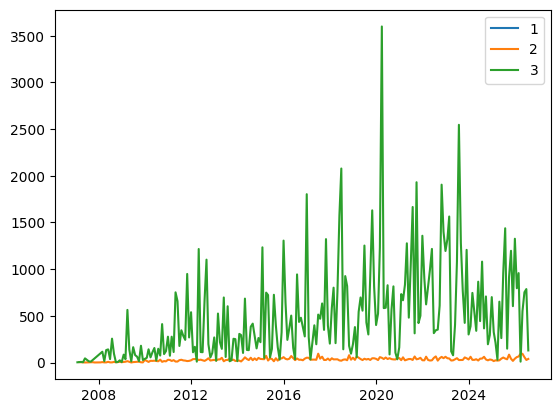

In [ ]:
query = """
SELECT clusters.CENTROID_ID,
       popularity.month,
       SUM(popularity.popularity) AS cluster_popularity
FROM ML.PREDICT(MODEL `data-mining-project-505611.hackernews_royalsflush.clustering`, (
  SELECT *
  FROM `hackernews_royalsflush.hackernews_embeddings`
)) AS clusters
JOIN `hackernews_royalsflush.hackernews_popularity` AS popularity
ON popularity.story_id = clusters.story_id
GROUP BY clusters.CENTROID_ID, popularity.month;
"""

df = client.query(query).to_dataframe()
df.set_index(['CENTROID_ID'], inplace=True)
df = df.sort_values(by=['CENTROID_ID', 'month'])
print(df)

fig, ax = plt.subplots()
for c in df.index.unique():
  ax.plot(df.loc[c]['month'], df.loc[c]['cluster_popularity'], label=c)

ax.legend()
plt.show()

In [102]:
query = """
SELECT clusters.CENTROID_ID,
       ful.story_id,
       ful.story_title,
       ful.story_text,
       ful.comments_text
FROM ML.PREDICT(MODEL `data-mining-project-505611.hackernews_royalsflush.clustering`, (
  SELECT *
  FROM `hackernews_royalsflush.hackernews_embeddings`
)) AS clusters
JOIN `hackernews_royalsflush.hackernews_full` AS ful
ON ful.story_id = clusters.story_id;
"""

def remove_noisy_tokens(text):
  text = text.replace(':', ' ')
  text = text.replace('"', ' ')
  text = text.replace('=', ' ')
  text = text.replace('>', ' ')
  text = text.replace('<', ' ')
  text = text.replace('/', ' ')
  text = text.replace('?', ' ')
  text = text.replace('-', ' ')
  text = text.replace('&#x27;', ' ')
  stoplist = set('for a of the and to in it that you with what i be is but on have this or was are '
                 'at my they not can if as from would https p href rel your an like so t s do their '
                 'all how we some more about when get show has by nofollow don no just which than will '
                 'http'.split())
  return ' '.join([word for word in text.lower().split() if word not in stoplist])

def concat_stories(cluster_id, data):
  titles = data.loc[cluster_id, 'story_title']
  if type(titles) is not str:
    titles = titles.to_numpy()
  texts = data.loc[cluster_id, 'story_text']
  if type(texts) is not str:
    texts = texts.to_numpy()
  comments = data.loc[cluster_id, 'comments_text']
  if type(comments) is not str:
    comments = comments.to_numpy()

  docs = []
  docs += [titles] if type(titles) is str else titles.tolist()
  docs += [texts] if type(texts) is str else texts.tolist()
  docs += [comments] if type(comments) is str else comments.tolist()
  return docs

def corpus_per_cluster(cluster_id, data):
  docs = concat_stories(cluster_id, data)
  texts = [
      remove_noisy_tokens(document).split()
      for document in docs
  ]

  # remove words that appear only once
  frequency = defaultdict(int)
  for text in texts:
      for token in text:
          frequency[token] += 1

  texts = [
      [token for token in text if frequency[token] > 1]
      for text in texts
  ]

  dictionary = corpora.Dictionary(texts)
  corpus = [dictionary.doc2bow(text) for text in texts]
  return corpus, dictionary

df = client.query(query).to_dataframe()
df.set_index(['CENTROID_ID'], inplace=True)

for c in df.index.unique():
  print(f"Cluster {c}")
  corr, dictt = corpus_per_cluster(c, df)
  tfidf = models.TfidfModel(corr)
  corpus_tfidf = tfidf[corr]
  lsi_model = models.LsiModel(corpus_tfidf, id2word=dictt, num_topics=2)
  corpus_lsi = lsi_model[corpus_tfidf]
  lsi_model.get_topics()
  print(lsi_model.print_topics())



Cluster 3
[(0, '0.162*"there" + 0.158*"people" + 0.125*"one" + 0.113*"think" + 0.105*"out" + 0.103*"even" + 0.102*"use" + 0.102*"because" + 0.100*"up" + 0.097*"who"'), (1, '0.735*"hn" + 0.631*"ask" + 0.069*"startup" + 0.064*"–" + 0.030*"ai" + -0.027*"people" + 0.025*"best" + 0.022*"code" + 0.022*"hacker" + 0.021*"developer"')]
Cluster 2
[(0, '-0.595*"–" + -0.531*"hn" + -0.207*"ask" + -0.173*"new" + -0.124*"open" + -0.117*"ai" + -0.112*"data" + -0.110*"code" + -0.109*"source" + -0.080*"why"'), (1, '0.597*"hn" + -0.549*"–" + -0.378*"new" + 0.336*"ask" + -0.069*"way" + 0.041*"there" + 0.034*"why" + 0.033*"built" + -0.033*"york" + -0.032*"security"')]
Cluster 1
[(0, '0.531*"java" + 0.531*"null" + 0.330*"funding" + 0.330*"reference" + 0.330*"research" + 0.330*"types"'), (1, '0.467*"java" + 0.467*"null" + -0.376*"funding" + -0.376*"reference" + -0.376*"research" + -0.376*"types"')]


In [91]:
from google import genai

from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

client_genai = genai.Client(api_key=GEMINI_API_KEY)

query = """
SELECT clusters.CENTROID_ID,
       ful.story_id,
       ful.story_title,
       ful.story_text,
       ful.comments_text
FROM ML.PREDICT(MODEL `data-mining-project-505611.hackernews_royalsflush.clustering`, (
  SELECT *
  FROM `hackernews_royalsflush.hackernews_embeddings`
)) AS clusters
JOIN `hackernews_royalsflush.hackernews_full` AS ful
ON ful.story_id = clusters.story_id;
"""

df = client.query(query).to_dataframe()
df.set_index(['CENTROID_ID'], inplace=True)

for c in df.index.unique():
  print(f"Cluster {c}")

  interaction = client_genai.interactions.create(
    model="gemini-3.6-flash",
    input="Tell me what's the most common topic in these sentences: " +"\n".join(concat_stories(c, df)[:100]),
  )
  print(interaction.output_text)


Cluster 3
The overall, overarching topic of these sentences is **Technology and Software Engineering** (specifically, topics typical of the **Hacker News** online community). 

Nearly all of the headlines/titles fit under this meta-category, which can be broken down into a few major recurring sub-topics:

### 1. Software Development & Programming
* **Languages & Frameworks:** *C++ tricks*, *Time in Go*, *Kivy (Python)*, *JEP 443 (Java)*, *Refactorator (Swift)*.
* **Developer Tools & Infrastructure:** *Highlights from Git 2.35*, *Compile-time version strings in CMake*, *Linux processes (Rcon)*, *JWTs*, *Netlify to Cloudflare Workers*.

### 2. Artificial Intelligence (AI) & Machine Learning
* *ChatGPT Advanced Data Analysis vs. Local Alternatives*
* *Release of Fugaku-LLM*
* *Using the new GPT-4 for good*
* *AI Apps for writing books & sports recaps*
* *Ask HN: How worried should I be about running LLM code on my machine?*

### 3. Tech Hardware, Chips & Systems
* *Intel Gen12/Xe Graphics

In [101]:
!pip install pytrends-modern

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.6 MB/s eta 0:00:00


                                month  cluster_popularity
CENTROID_ID                                              
1           2015-11-01 00:00:00+00:00                   5
2           2007-03-01 00:00:00+00:00                   5
2           2007-05-01 00:00:00+00:00                   3
2           2007-06-01 00:00:00+00:00                   1
2           2007-09-01 00:00:00+00:00                   4
...                               ...                 ...
3           2026-04-01 00:00:00+00:00                  10
3           2026-05-01 00:00:00+00:00                 550
3           2026-06-01 00:00:00+00:00                 753
3           2026-07-01 00:00:00+00:00                 787
3           2026-08-01 00:00:00+00:00                 130

[458 rows x 2 columns]


/tmp/ipykernel_1221/3226038182.py:33: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  normalized_df=((df-df.min()) * 100)/(df.max()-df.min())


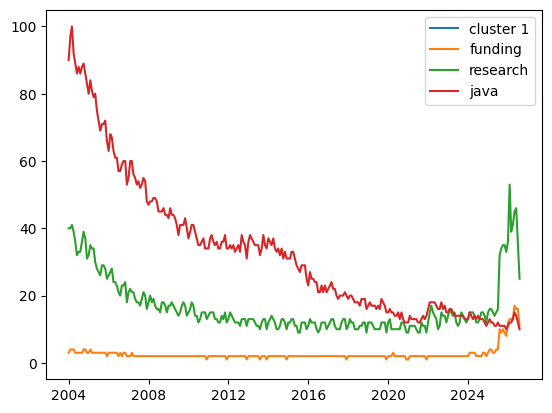

/tmp/ipykernel_1221/3226038182.py:33: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  normalized_df=((df-df.min()) * 100)/(df.max()-df.min())


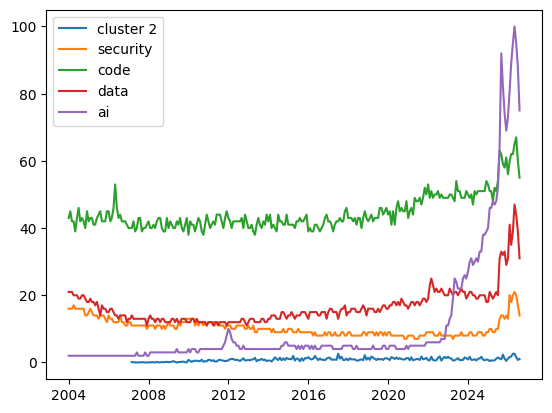

/tmp/ipykernel_1221/3226038182.py:33: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  normalized_df=((df-df.min()) * 100)/(df.max()-df.min())


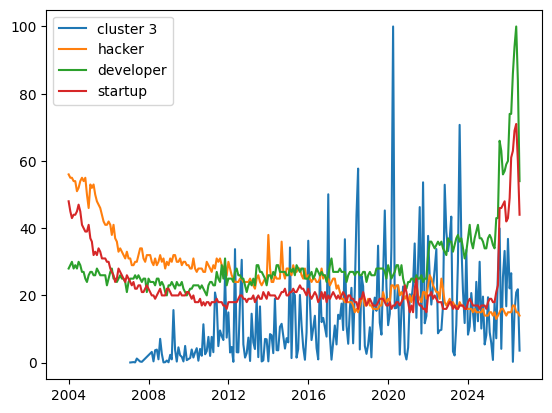

In [115]:
from pytrends_modern import TrendReq

pytrends = TrendReq(hl='en-US', tz=0)
pytrends.build_payload(
    kw_list=['funding', 'research', 'java'],
    timeframe='all',
    geo='', # Default is world
)

query = """
SELECT clusters.CENTROID_ID,
       popularity.month,
       SUM(popularity.popularity) AS cluster_popularity
FROM ML.PREDICT(MODEL `data-mining-project-505611.hackernews_royalsflush.clustering`, (
  SELECT *
  FROM `hackernews_royalsflush.hackernews_embeddings`
)) AS clusters
JOIN `hackernews_royalsflush.hackernews_popularity` AS popularity
ON popularity.story_id = clusters.story_id
GROUP BY clusters.CENTROID_ID, popularity.month;
"""

df = client.query(query).to_dataframe()
df.set_index(['CENTROID_ID'], inplace=True)
keywords = [['funding', 'research', 'java']]
keywords+= [['security', 'code', 'data', 'ai']]
keywords+= [['hacker', 'developer', 'startup']]
df = df.sort_values(by=['CENTROID_ID', 'month'])
print(df)

for c in df.index.unique():
  fig, ax = plt.subplots()
  normalized_df=((df-df.min()) * 100)/(df.max()-df.min())
  ax.plot(df.loc[c]['month'], normalized_df.loc[c]['cluster_popularity'], label=f"cluster {c}")
  pytrends.build_payload(
    kw_list=keywords[c-1],
    timeframe='all',
    geo='', # Default is world
  )
  interest_df = pytrends.interest_over_time()
  for k in keywords[c-1]:
    ax.plot(interest_df.index, interest_df[k], label=k)

  ax.legend()
  plt.show()

# Appendix

Attempts that didn't work

In [ ]:
# Creates the embeddings and runs the clustering
#
# Rejected, this for some reason takes too long, even when limited by 10k
# samples. My humble TF embeddings calculation fares better.

query = """
CREATE OR REPLACE MODEL
`data-mining-project-505611.hackernews_royalsflush.clustering`
REMOTE WITH CONNECTION `projects/data-mining-project-505611/locations/us/connections/hackernews_royalsflush`
OPTIONS (ENDPOINT = 'gemini-embedding-001');
"""

resp = client.query(query)
print(resp)

query = """
SELECT *
FROM
  AI.GENERATE_EMBEDDING(
    MODEL hackernews_royalsflush.clustering,
    (
      SELECT story_title AS title,
              CONCAT(story_text, url_content, comments_text) AS content
      FROM hackernews_royalsflush.hackernews_full
    ),
      STRUCT('CLUSTERING' AS task_type)
);
"""